In [1]:

# !pip install "nbformat>=4.2.0"
# pip install --upgrade notebook jupyter_client


In [2]:
import numpy as np
import networkx as nx
from omegaconf import OmegaConf

from matplotlib import cm
from matplotlib import colormaps
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from mpl_toolkits.axes_grid1 import make_axes_locatable

import torch
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
from torch_geometric.explain import Explainer, ModelConfig, GNNExplainer

from src.gnn.model.model import GraphRegressorV2

import warnings
warnings.filterwarnings("ignore")

def plot_gnn_explanation_3d(
    data,
    explanation,
    node_positions,
    need_transparency: bool = True,
    node_size: int = 2,
    edge_width: float = 1.0,
    percentile_clip=(2, 98),
    title: str = "GNN Explainer – Graph-level 3D",
):

    G = nx.Graph()
    row, col = data.edge_index
    G.add_edges_from(zip(row.tolist(), col.tolist()))

    node_importance = explanation.node_mask.detach().cpu().numpy()
    edge_importance = explanation.edge_mask.detach().cpu().numpy()

    combined = np.concatenate([node_importance.ravel(), edge_importance.ravel()])
    vmin, vmax = np.percentile(combined, percentile_clip)

    node_norm = np.clip((node_importance - vmin) / (vmax - vmin), 0, 1)
    edge_norm = np.clip((edge_importance - vmin) / (vmax - vmin), 0, 1)

    cmap = cm.get_cmap('RdBu_r')

    node_colors = []
    for n in node_norm:
        r, g, b, a = np.array(cmap(n)).flatten()  # 안전하게 RGBA unpack
        if need_transparency:
            node_colors.append(f'rgba({int(r*255)},{int(g*255)},{int(b*255)},{a:.2f})')
        else:
            node_colors.append(f'rgb({int(r*255)},{int(g*255)},{int(b*255)})')

    edge_colors = []
    for e in edge_norm:
        r, g, b, a = np.array(cmap(e)).flatten()
        if need_transparency:
            edge_colors.append(f'rgba({int(r*255)},{int(g*255)},{int(b*255)},{a:.2f})')
        else:
            edge_colors.append(f'rgb({int(r*255)},{int(g*255)},{int(b*255)})')

    x_nodes, y_nodes, z_nodes = node_positions[:,0], node_positions[:,1], node_positions[:,2]

    edge_x, edge_y, edge_z = [], [], []
    for i, j in G.edges():
        x0, y0, z0 = node_positions[i]
        x1, y1, z1 = node_positions[j]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_z += [z0, z1, None]

    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode='lines',
        line=dict(width=edge_width, color='grey'),
        hoverinfo='none'
    )

    node_trace = go.Scatter3d(
        x=x_nodes, y=y_nodes, z=z_nodes,
        mode='markers',
        marker=dict(size=node_size, color=node_colors),
        text=[f'Node {i}' for i in range(len(x_nodes))],
        hoverinfo='text'
    )

    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(
        title=title,
        showlegend=False,
        scene=dict(
            xaxis=dict(showbackground=False),
            yaxis=dict(showbackground=False),
            zaxis=dict(showbackground=False)
        )
    )
    fig.show()


def plot_gnn_explanation(
    data,
    explanation,
    node_positions,
    need_transparency: bool = True,
    figsize=(15, 15),
    node_size: int = 12,
    edge_width: float = 1.0,
    percentile_clip=(2, 98),
    title: str = "GNN Explainer – Graph-level",
):

    G = to_networkx(data, to_undirected=True)

    node_importance = explanation.node_mask.detach().cpu().numpy()
    edge_importance = explanation.edge_mask.detach().cpu().numpy()

    combined = np.concatenate([node_importance.ravel(), edge_importance.ravel()])
    vmin, vmax = np.percentile(combined, percentile_clip)

    row, col = data.edge_index
    edge_list = list(zip(row.tolist(), col.tolist()))
    pos = {i: (coord[0], coord[1]) for i, coord in enumerate(node_positions)}

    node_norm = np.clip((node_importance - vmin) / (vmax - vmin), 0, 1)
    edge_norm = np.clip((edge_importance - vmin) / (vmax - vmin), 0, 1)

    if need_transparency:
        node_colors = cm.RdBu_r(node_norm)
        node_colors[:, -1] = node_norm  # alpha에 중요도 반영
        edge_colors = cm.RdBu_r(edge_norm)
        edge_colors[:, -1] = edge_norm
    else:
        node_colors = cm.RdBu_r(node_norm)[:, :3]
        edge_colors = cm.RdBu_r(edge_norm)[:, :3]

    fig, ax = plt.subplots(figsize=figsize)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_size,
        node_color=node_colors,
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edge_list,
        edge_color=edge_colors,
        width=edge_width,
        ax=ax,
    )

    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title)

    divider = make_axes_locatable(ax)
    cax_left = divider.append_axes("left", size="4%", pad=0.35)
    cax_right = divider.append_axes("right", size="4%", pad=0.35)

    sm_edges = cm.ScalarMappable(cmap=cm.RdBu_r, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar_edges = fig.colorbar(sm_edges, cax=cax_left)
    cbar_edges.set_label("Edge Importance")
    cax_left.yaxis.set_ticks_position("left")
    cax_left.yaxis.set_label_position("left")

    sm_nodes = cm.ScalarMappable(cmap=cm.RdBu_r, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cbar_nodes = fig.colorbar(sm_nodes, cax=cax_right)
    cbar_nodes.set_label("Node Importance")

    fig.tight_layout()
    return fig, ax


def plot_gnn_explanation_matplotlib(data, explanation, node_positions, 
                                   need_transparency=False,
                                   figsize=(8,8), node_size=5, edge_width=1,
                                   percentile_clip=99, title="GNN Explanation",
                                   dim=2):
    """
        dim: 2 또는 3
    """
    G = nx.Graph()
    edge_index = data.edge_index.cpu().numpy()
    G.add_edges_from(edge_index.T)
    
    # 중요도
    node_imp = explanation.node_mask.detach().cpu().numpy()
    edge_imp = explanation.edge_mask.detach().cpu().numpy()
    
    combined = np.concatenate([node_imp.ravel(), edge_imp.ravel()])
    vmin, vmax = np.percentile(combined, [0, percentile_clip])
    
    fig = plt.figure(figsize=figsize)
    if dim == 3:
        from mpl_toolkits.mplot3d import Axes3D
        ax = fig.add_subplot(111, projection='3d')
    else:
        ax = fig.add_subplot(111)
    
    if dim == 3:
        sc_nodes = ax.scatter(node_positions[:,0], node_positions[:,1], node_positions[:,2],
                              c=node_imp, cmap=cm.RdBu_r, s=node_size,
                              alpha=0.8 if need_transparency else 1.0)
    else:
        sc_nodes = ax.scatter(node_positions[:,0], node_positions[:,1],
                              c=node_imp, cmap=cm.RdBu_r, s=node_size,
                              alpha=0.8 if need_transparency else 1.0)

    for i, (u, v) in enumerate(G.edges()):
        if dim == 3:
            x = [node_positions[u,0], node_positions[v,0]]
            y = [node_positions[u,1], node_positions[v,1]]
            z = [node_positions[u,2], node_positions[v,2]]
            color = cm.RdBu_r((edge_imp[i]-vmin)/(vmax-vmin))
            ax.plot(x, y, z, color=color, linewidth=edge_width)
        else:
            x = [node_positions[u,0], node_positions[v,0]]
            y = [node_positions[u,1], node_positions[v,1]]
            color = cm.RdBu_r((edge_imp[i]-vmin)/(vmax-vmin))
            ax.plot(x, y, color=color, linewidth=edge_width)
 
    cbar_nodes = fig.colorbar(sc_nodes, ax=ax, shrink=0.5, pad=0.1)
    cbar_nodes.set_label("Node Importance")

    sm_edges = cm.ScalarMappable(cmap=cm.RdBu_r, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm_edges.set_array([])
    cbar_edges = fig.colorbar(sm_edges, ax=ax, shrink=0.5, pad=0.05)
    cbar_edges.set_label("Edge Importance")
    
    ax.set_title(title)
    plt.show()



class ExplainerWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x, edge_index, edge_attr=None, batch=None, global_x=None, **kwargs):
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, global_x=global_x)
        if edge_attr is not None:
            data.edge_attr = edge_attr
        if batch is None:
            device = x.device
            data.batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
        else:
            data.batch = batch

        return self.base_model(data)


In [3]:
test_dataset_path = 'output/gnn/field/test_datapyg_dataset_added_dni.pt'
model_ckpt_path = "output/gnn/field/best_model_gin.pt"
config_path = "output/gnn/field/gin_3_new_5.yaml"
need_transparency = True

test_dataset = torch.load(test_dataset_path, weights_only=False)
data = test_dataset[1300]

In [4]:
x = data.x
edge_index = data.edge_index
node_positions =  data.x[:, :2] # [num_nodes, 2]
node_positions_3d =  data.x[:, :3] # [num_nodes, 3]
global_x = data.global_x
edge_attr = data.edge_attr


config = OmegaConf.load(config_path)

model = GraphRegressorV2(
    gnn_type="gin",
    config=config.model_config,
)

model.load_state_dict(torch.load(model_ckpt_path, map_location=torch.device("mps")))
wrapped_model = ExplainerWrapper(model)

In [5]:
explainer = Explainer(
    model=wrapped_model,
    explanation_type='model',
    algorithm=GNNExplainer(epochs=100),  # 여기서 GNNExplainer 사용
    model_config=ModelConfig(
        mode='regression',
        task_level='graph',
    ),
    node_mask_type='object',
    edge_mask_type='object',
)


In [6]:
explanation = explainer(x=x, edge_index=edge_index, global_x=global_x, edge_attr=edge_attr)
node_mask = explanation.get('node_mask')
edge_mask = explanation.get('edge_mask')


(<Figure size 800x800 with 3 Axes>,
 <Axes: title={'center': 'GNN Explainer – Graph-level'}>)

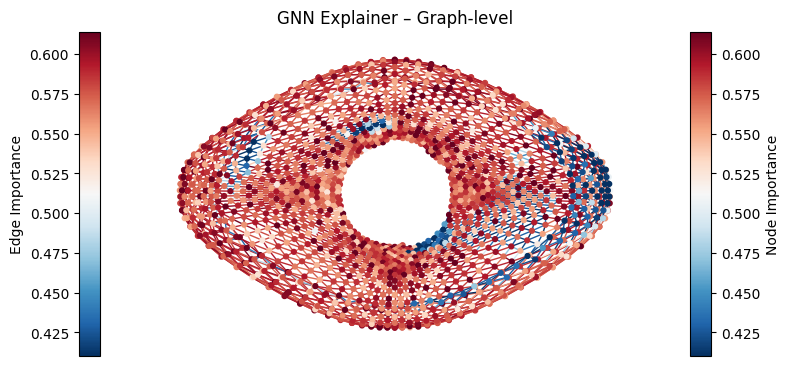

In [10]:
plot_gnn_explanation(data, explanation, node_positions, need_transparency=False, figsize=(8, 8))

(<Figure size 800x800 with 3 Axes>,
 <Axes: title={'center': 'GNN Explainer – Graph-level'}>)

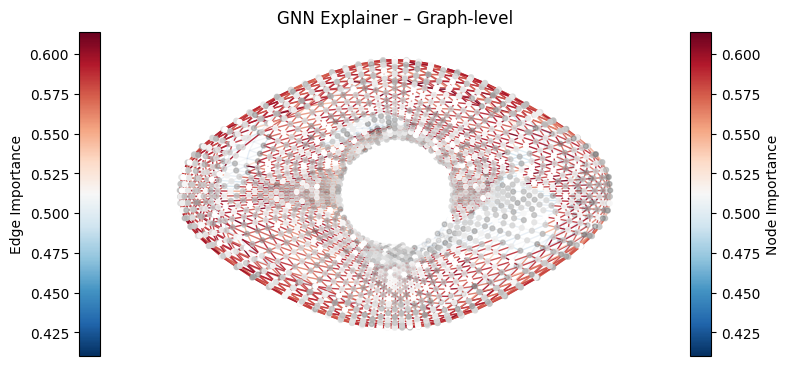

In [7]:
plot_gnn_explanation(data, explanation, node_positions, need_transparency=True, figsize=(8, 8))

(<Figure size 1500x1500 with 3 Axes>,
 <Axes: title={'center': 'GNN Explainer – Graph-level'}>)

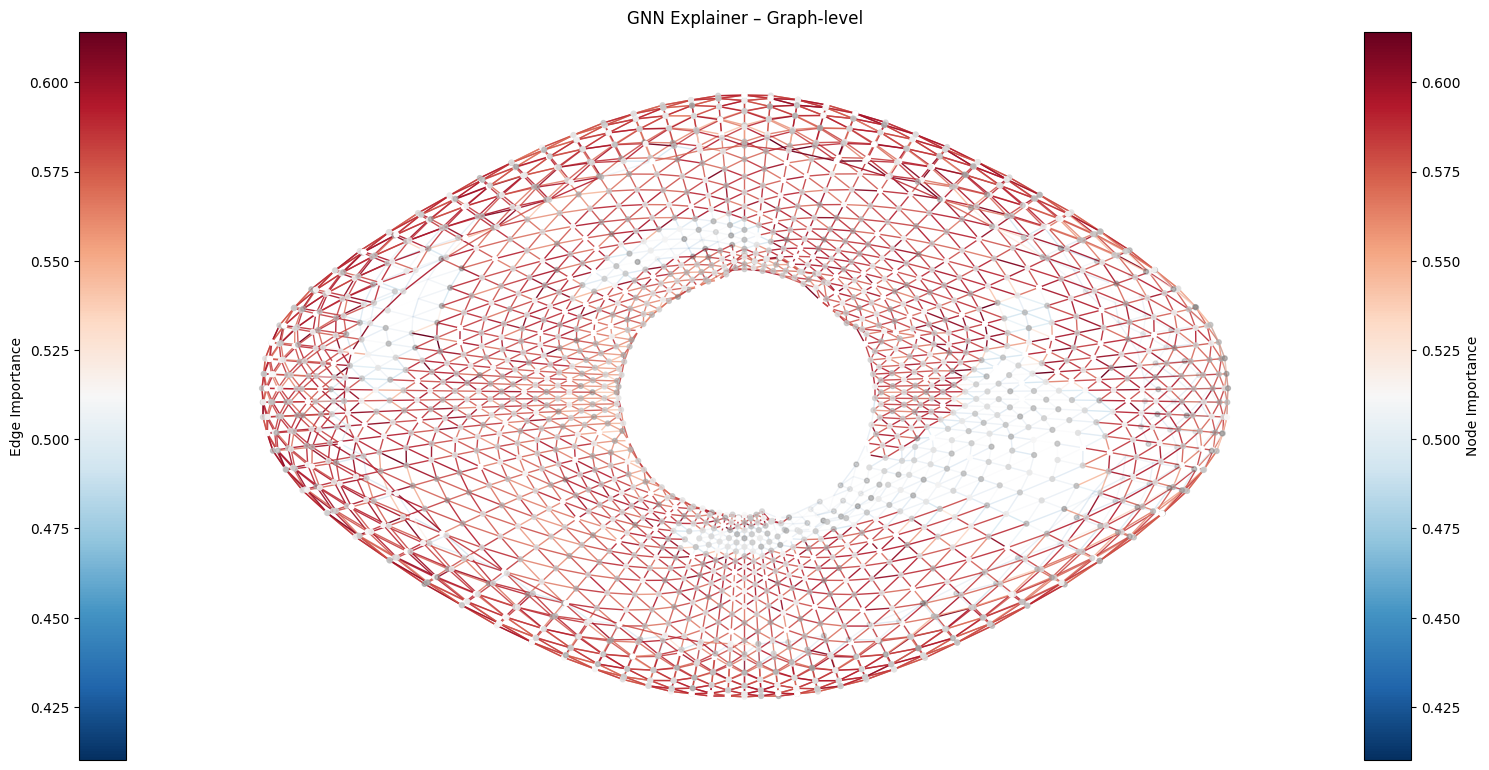

In [8]:
plot_gnn_explanation(data, explanation, node_positions, need_transparency=True, figsize=(15, 15))

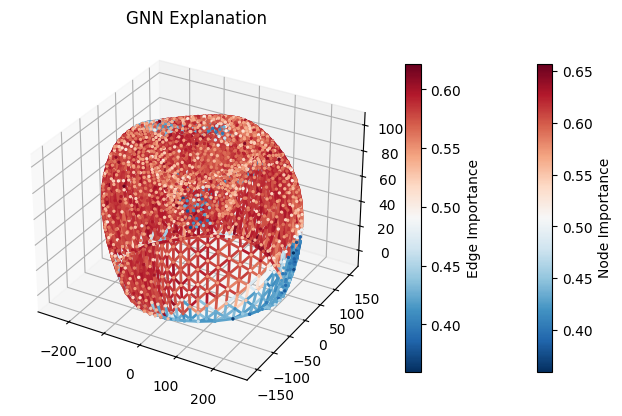

In [12]:
plot_gnn_explanation_matplotlib(
    data,
    explanation,
    node_positions_3d,
    need_transparency=False,
    figsize=(8, 8),
    node_size=2,
    edge_width=2,
    dim=3
)

In [13]:
plot_gnn_explanation_3d(data, explanation, node_positions_3d, need_transparency=False)